# Final Project
## Kenny Nguyen
## DATA 201

Presentation Link
[link text](https://montgomerycollege0-my.sharepoint.com/:p:/g/personal/knguy250_montgomerycollege_edu/IQANEPKKII6jRb4RsSpgvk8FAZI0oCUFPsfFpU41TsR79BM?e=ReB5sM&nav=eyJzSWQiOjI2NCwiY0lkIjoyNzIzOTIyMjk3fQ)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve, classification_report
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import precision_score, recall_score, f1_score


In [ ]:
videogames = pd.read_csv("vgsales.csv")

In [ ]:
videogames.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [ ]:
videogames.shape

(16598, 11)

In [ ]:
videogames.columns

Index(['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales'],
      dtype='object')

| Variable                 | Description                                                      | Type         |
|--------------------------|------------------------------------------------------------------|--------------|
|Rank| Ranking of overall sales|Categorical|
|Name| Name of the video game|Categorical|
|Platform| The platform the game was released on | Categorical|
|Year|Year the game was released| Categorical  |
|Genre|Genre of the game | Categorical |
|Publisher| Publisher of the game|Categorical |
|NA_Sales| Sales in North America (In millions)| Quantitative|
|EU_Sales|Sales in Europe (In millions)| Quantitative |
|JP_Sales|Sales in Japan (In millions)| Quantitative |
|Other_Sales|Sales in the rest of the world (In millions)|Quantitative |
|Global_Sales|Total worldwide sales (In millions)| Quantitative |

In [ ]:
videogames = videogames.dropna()

In [ ]:
videogames['Publisher'].value_counts().head(10)

,count
Publisher,
Electronic Arts,1339
Activision,966
Namco Bandai Games,928
Ubisoft,918
Konami Digital Entertainment,823
THQ,712
Nintendo,696
Sony Computer Entertainment,682
Sega,632


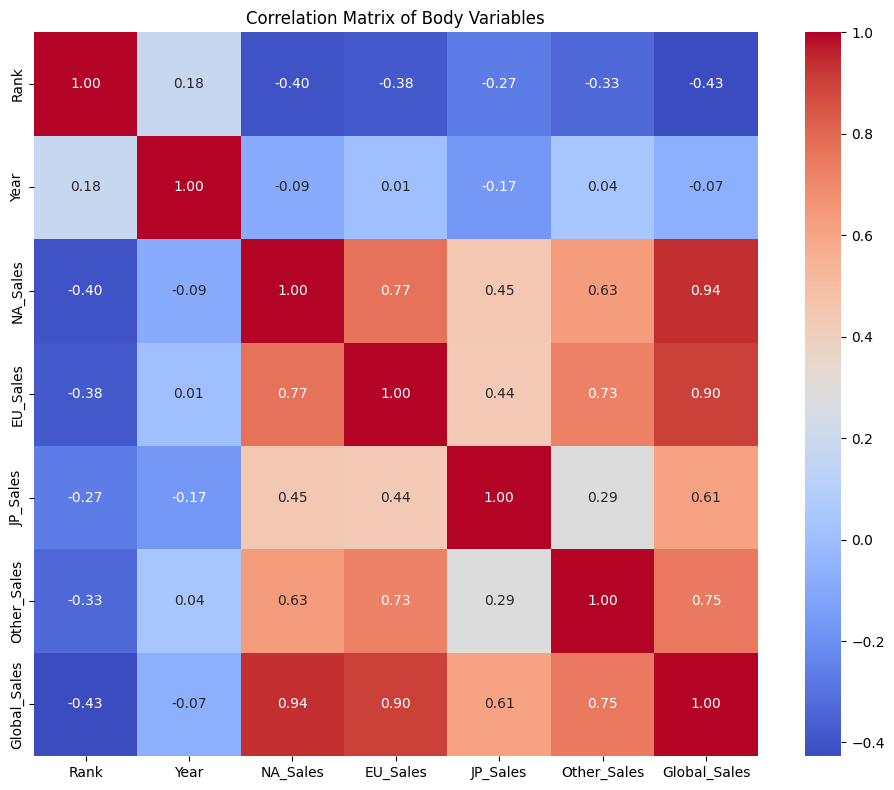

In [ ]:
corr_matrix = videogames.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix of Body Variables")
plt.tight_layout()
plt.show()

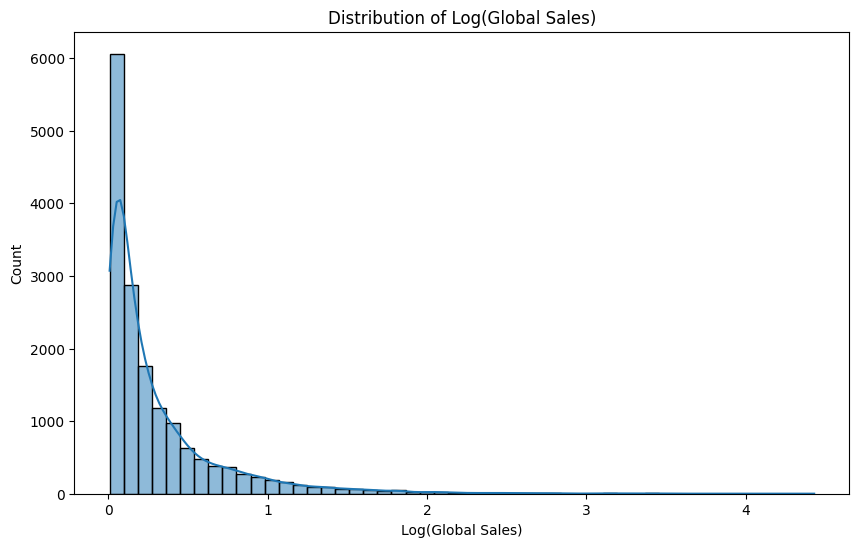

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(videogames['Global_Sales']), kde=True, bins=50)
plt.title('Distribution of Log(Global Sales)')
plt.xlabel('Log(Global Sales)')
plt.show()

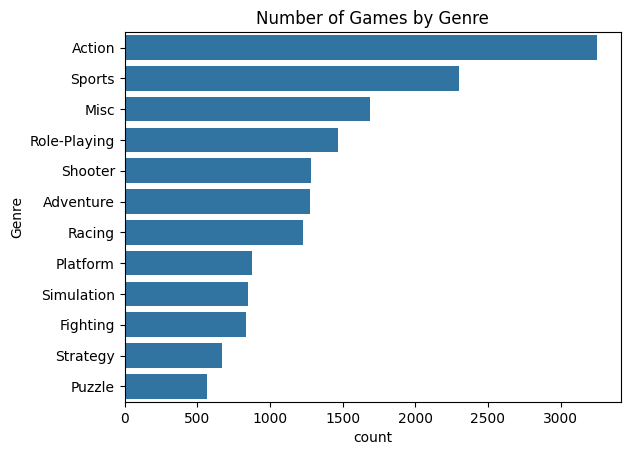

In [ ]:
sns.countplot(data=videogames, y='Genre', order=videogames['Genre'].value_counts().index)
plt.title("Number of Games by Genre")
plt.show()

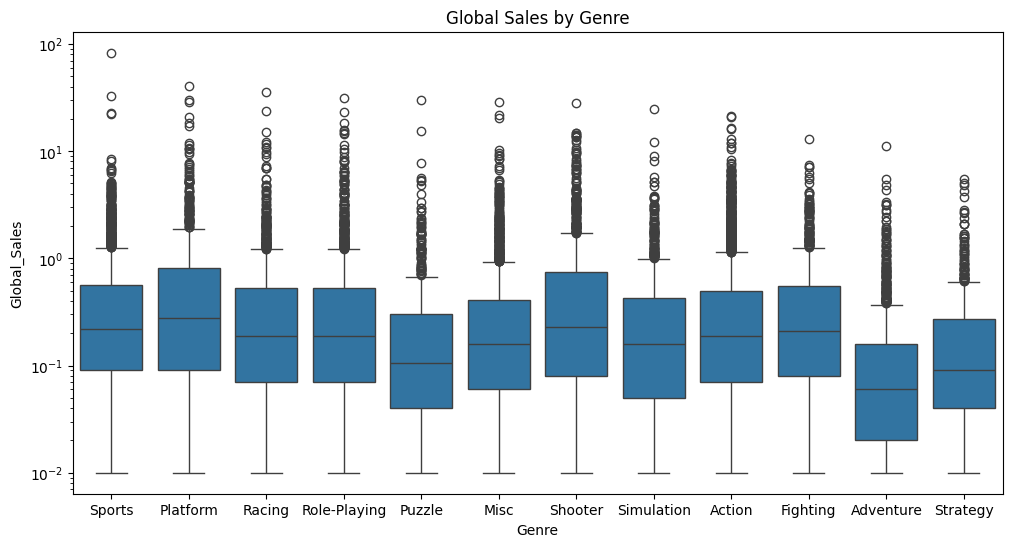

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Genre', y='Global_Sales', data=videogames)
plt.yscale('log')
plt.title('Global Sales by Genre')

plt.show()

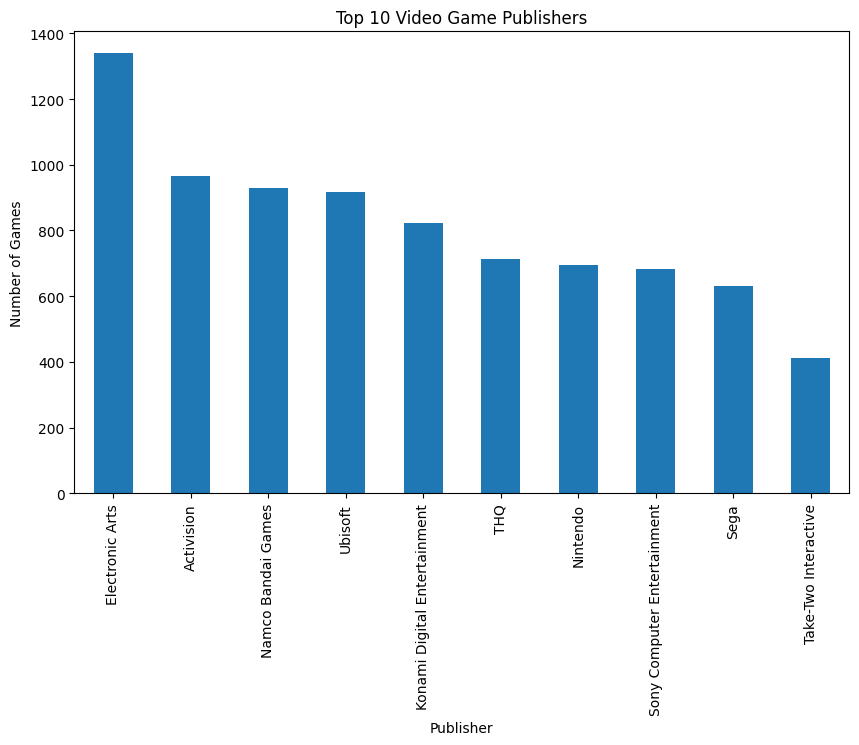

In [ ]:
top_publishers = videogames['Publisher'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_publishers.plot(kind='bar')
plt.title("Top 10 Video Game Publishers")
plt.ylabel("Number of Games")
plt.show()

# Regression

What regional markets
drive global sales?

In [ ]:
X_train_sm_reg = sm.add_constant(X_train)

ols_model = sm.OLS(y_train, X_train_sm_reg)
ols_results = ols_model.fit()

regression_coefficients = pd.DataFrame({
    'Variable': ols_results.params.index,
    'Coefficient': ols_results.params.values,
    'Std. Error': ols_results.bse.values,
    't-statistic': ols_results.tvalues.values,
    'P>|t|': ols_results.pvalues.values
})

print("\nLinear Regression Coefficients and Statistics:")
print(regression_coefficients.to_markdown(index=False))


Linear Regression Coefficients and Statistics:
| Variable   |   Coefficient |   Std. Error |   t-statistic |       P>|t| |
|:-----------|--------------:|-------------:|--------------:|------------:|
| const      |    5.63526    |   0.635899   |       8.86187 | 9.03319e-19 |
| NA_Sales   |    0.0543439  |   0.00340723 |      15.9496  | 1.17412e-56 |
| EU_Sales   |    0.0204343  |   0.00572974 |       3.56636 | 0.000363454 |
| Year       |   -0.00279583 |   0.00031691 |      -8.82215 | 1.2859e-18  |


In [ ]:
y = videogames['Global_Sales']
X = videogames[['NA_Sales',
       'EU_Sales', 'Year'
                ]]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
y_test

,Global_Sales
3527,0.57
12216,0.07
7940,0.19
3030,0.67
7144,0.22
...,...
1342,1.44
5700,0.31
6033,0.29
3828,0.52


# Linear Regression

In [ ]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("RMSE:", rmse_linear)
print("R²:", r2_linear)


Linear Regression Results
RMSE: 0.3302789457191529
R²: 0.967411180075481


## Random Forest Regressor

In [ ]:
rf_reg = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_reg.fit(X_train, y_train)

y_pred_rf = rf_reg.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R²:", r2_rf)

Random Forest RMSE: 0.7390102984083103
Random Forest R²: 0.8368422016693544


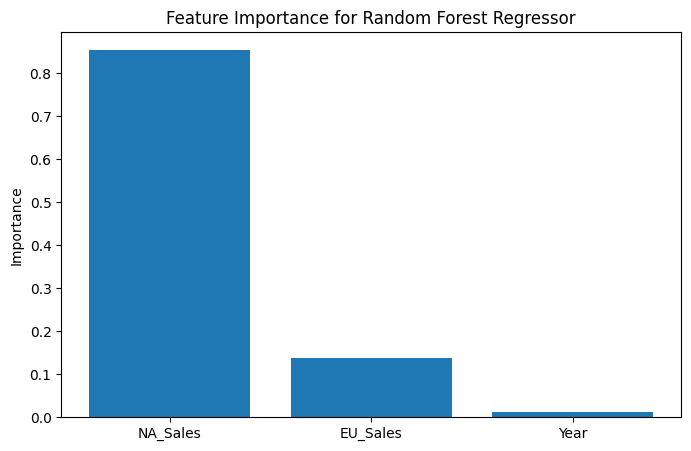

In [ ]:
importance = rf_reg.feature_importances_

features = X_train.columns

plt.figure(figsize=(8,5))
plt.bar(features, importance)
plt.title("Feature Importance for Random Forest Regressor")
plt.ylabel("Importance")
plt.show()

## Cross Validation

In [ ]:
depths = list(range(1, 13))

cv_rmse = []

for d in depths:

    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=d,
        random_state=42
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error"
    )

    cv_rmse.append(-scores.mean())

best_depth = depths[int(np.argmin(cv_rmse))]

print("\nBest max depth by 5-fold CV:", best_depth)





Best max depth by 5-fold CV: 9


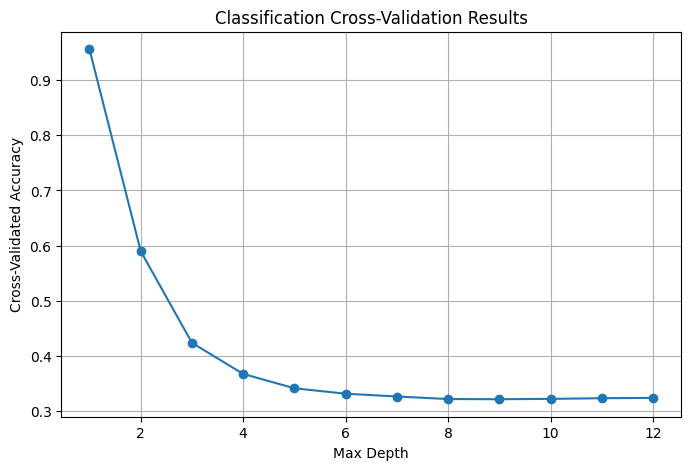

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(depths, cv_rmse, marker='o')

plt.xlabel("Max Depth")
plt.ylabel("Cross-Validated Accuracy")

plt.title("Classification Cross-Validation Results")

plt.grid(True)

plt.show()

# Classification

Can regional sales and
release characteristics predict if a game is
published by Nintendo?

In [ ]:
videogames['Is_Nintendo'] = (videogames['Publisher'] == 'Nintendo').astype(int)
videogames = videogames.dropna(subset=['NA_Sales', 'EU_Sales', 'Year', 'Global_Sales'])

In [ ]:
X = videogames[['NA_Sales', 'EU_Sales', 'Year']]
y = videogames['Is_Nintendo']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Logistic Regression

In [ ]:
model_sk = LogisticRegression()

model_sk.fit(X_train, y_train)

y_train_pred = model_sk.predict(X_train)
y_pred = model_sk.predict(X_test)
y_prob = model_sk.predict_proba(X_test)
y_prob

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_pred)

print("Logistic Regression Results:")
print(f"  Training Accuracy: {train_acc:.4f}")
print(f"  Testing Accuracy: {test_acc:.4f}")
print()

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print()

auc = roc_auc_score(y_test, y_prob[:, 1])
print(f"AUC: {auc:.4f}")

Logistic Regression Results:
  Training Accuracy: 0.9575
  Testing Accuracy: 0.9566

Confusion Matrix:
[[4665   17]
 [ 195   11]]

AUC: 0.6802


In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob[:, 1])

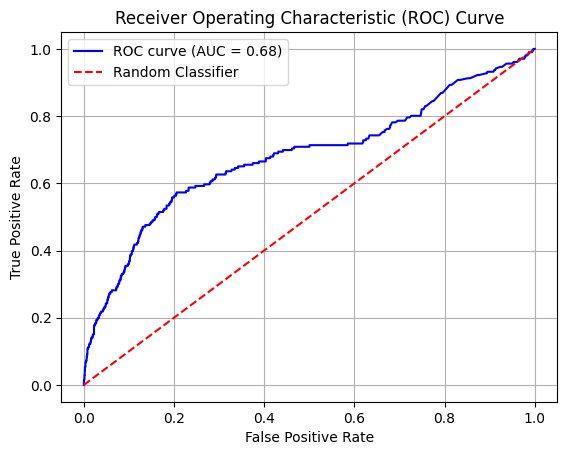

In [ ]:
plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

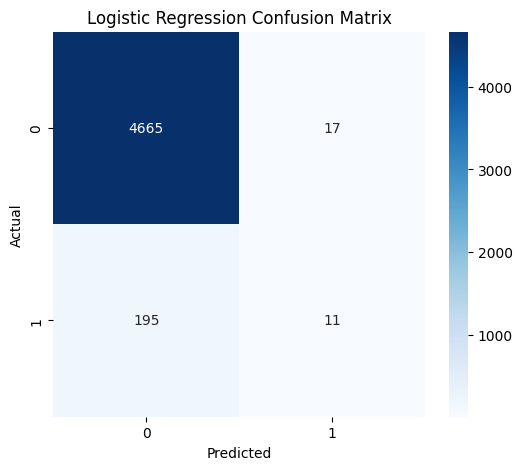

In [ ]:
cm_lr = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Decision Tree

In [ ]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.96      0.97      0.97      4682
           1       0.24      0.18      0.20       206

    accuracy                           0.94      4888
   macro avg       0.60      0.58      0.59      4888
weighted avg       0.93      0.94      0.94      4888



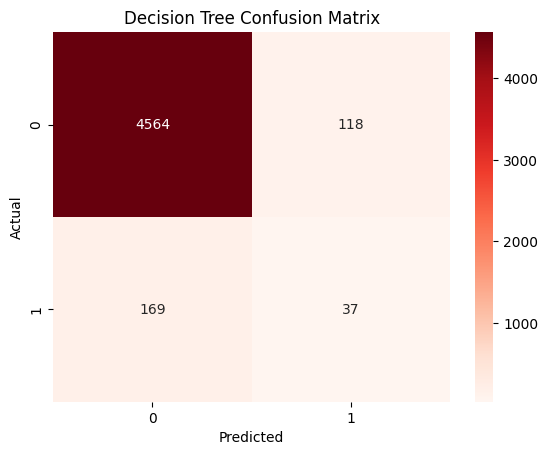

In [ ]:
cm = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(
    cm, annot=True,
    fmt='d',
    cmap='Reds'
    )
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Random Forest

In [ ]:
rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98      4682
           1       0.40      0.10      0.16       206

    accuracy                           0.96      4888
   macro avg       0.68      0.55      0.57      4888
weighted avg       0.94      0.96      0.94      4888



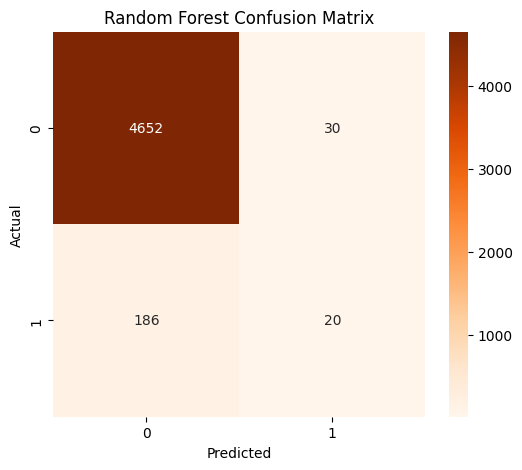

In [ ]:
y_pred_rf = rf_clf.predict(X_test)
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Classification Cross Validation

In [ ]:
depths = list(range(1, 13))

cv_accuracy = []

for d in depths:

    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=d,
        random_state=42
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    cv_accuracy.append(scores.mean())

best_depth = depths[int(np.argmax(cv_accuracy))]

print("\nBest Classification Depth:", best_depth)



Best Classification Depth: 6


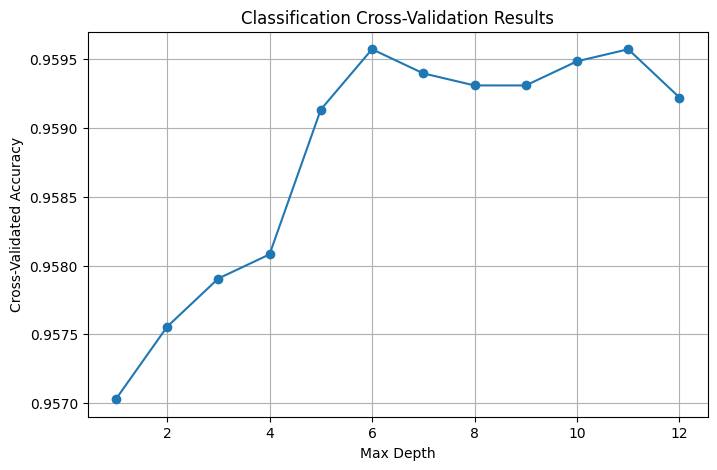

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(depths, cv_accuracy, marker='o')

plt.xlabel("Max Depth")
plt.ylabel("Cross-Validated Accuracy")

plt.title("Classification Cross-Validation Results")

plt.grid(True)

plt.show()

In [ ]:
classification_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ]
})

print(classification_results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.956628   0.392857  0.053398  0.094017
1        Decision Tree  0.941285   0.238710  0.179612  0.204986
2        Random Forest  0.955810   0.400000  0.097087  0.156250
